In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)
x = 20 * np.random.rand(50, 1)

# create scores (y = 4 * hours + random noise)
y = 4 * x + np.random.randn(50, 1) * 5

# visualize it
plt.scatter(x,y)
plt.xlabel('study hours')
plt.ylabel('exam score')
plt.show()


In [4]:
from sklearn.linear_model import LinearRegression

# initialize the brain
model = LinearRegression()

# train the model
model.fit(x, y)

# Make a prediction: if I study for 15 hourse, what's my score?
prediction = model.predict([[25.2]])
print(f'Predicted score for 15 hours: {prediction[0][0]:.2f}')
print(model.coef_)

In [5]:
print(model.coef_)
print(model.intercept_)
print(model.score(x, y))


In [6]:
from sklearn.model_selection import train_test_split # used to splitting data
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# train only on training data
model.fit(x_train, y_train)

# predict on the unseen test data
y_pred = model.predict(x_test)

# check the damage (error)
mse = mean_squared_error(y_test, y_pred)
print(y_test)
print(r2_score(y_test,y_pred))
print(f'coefficient: {model.coef_}')
print(f'mean squared error: {mse:.2f}')

In [7]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

# fit transform x_train
trans_x_train = poly.fit_transform(x_train)

model.fit(trans_x_train, y_train)

trans_x_test = poly.transform(x_test)

y_pred = model.predict(trans_x_test)

mse = mean_squared_error(y_test, y_pred)

print(f'mse: {mse}')
print(f'coefficience: {model.coef_}')

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# create labels: if score > 40, pass (1), else fail (0)
y_class = (y > 40).astype(int).flatten()
x_train, x_test, y_train, y_test = train_test_split(x, y_class, test_size=0.2, random_state=42)

# train logistic regression
clf = LogisticRegression()
clf.fit(x_train, y_train)

# predict
y_pred = clf.predict(x_test)
print(x_test[:4])
print(y_pred[:4])
print(f"accuracy: {accuracy_score(y_test, y_pred)*100}%")
print(confusion_matrix(y_test, y_pred))

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

# scaling (standization) - makes mean = 0 and variance = 1
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# the random forest
rf = RandomForestClassifier(n_estimators=100, max_depth=1, random_state=42) # 100 trees working together
rf.fit(x_train, y_train)
importances = rf.feature_importances_
plt.figure(figsize=(10,6))
plot_tree(rf.estimators_[0], filled = True, feature_names=['x_feature'])
plt.title("Visualizing 1 of the 100 trees")
plt.show()
print(f"Feature Importance: {importances}\n")

print(f"RF accuracy: {rf.score(x_test, y_test)* 100}%")

In [10]:
thresholds = [tree.tree_.threshold[0] for tree in rf.estimators_]

# plot a histogram of the thresholds
plt.figure(figsize=(10,4))
plt.hist(thresholds, bins=15, color='skyblue', edgecolor='black')
plt.title('visualization of the threshold in the 100 trees of the randomforest')
plt.xlabel('x_feature threshold value')
plt.ylabel('Number of trees')
plt.show()

print(f'average cutoff: {sum(thresholds)/len(thresholds):.3f}')
print(f'unique count: {(np.unique_counts(thresholds))}')

In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# mini dataset
emails = ['Get rich quick! Click here', 'Hey, are we meeting for coffee?', 'Free money now', 'Project report is due tomorrow']

labels = [1, 0, 1, 0] # 1 = spam, 0 = not spam

# convert text to numbers (vectorization)
vectorizer = CountVectorizer(ngram_range=(1,2))
x_counts = vectorizer.fit_transform(emails)

# use naive bayes (the king of simple text classification)
nb_model = MultinomialNB()
nb_model.fit(x_counts, labels)

# test it
test_email = ['Not free for coffee.']
test_counts = vectorizer.transform(test_email)
prediction = nb_model.predict(test_counts)


print(f'Prediction (1=spam, 0=clean): {prediction[0]}')
print(vectorizer.get_feature_names_out())

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim


# convert our data to pytorch tensors
x_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

# define the architecture
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.hidden1 = nn.Linear(1, 10) # 1 input -> 10 hidden neurons
        self.hidden2 = nn.Linear(10, 20) # 20 neurons
        self.output = nn.Linear(20, 1) # 10 hidden -> 1 output
        self.sigmoid = nn.Sigmoid()  # squash to 0 or 1

    def forward(self, x):
        x = torch.relu(self.hidden1(x)) # activation function (the 'spark')
        x = torch.relu(self.hidden2(x))
        x = self.sigmoid(self.output(x))
        return x
    
model = SimpleNet()
print(sum(p.numel() for p in model.parameters()))

In [13]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    # Forward pass: Get predictions
    predictions = model(x_tensor)

    # calculate loss
    loss = criterion(predictions, y_tensor)

    # zero the gradients ( standard pythor step)
    optimizer.zero_grad()

    # backpropagation ( the magic part )
    loss.backward()
    #update the weights
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, loss: {loss.item():.4f}')

In [14]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
import torch

model_name = "google-t5/t5-small"

# 1. Load Model and Tokenizer (This will download about 1.6GB)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

text_to_summarize = """In the Gaussian process viewpoint, we dispense with the parametric model and instead define a prior probability distribution over functions directly. At first sight, it might seem difficult to work with a distribution over the uncountably infinite space of functions. However, as we shall see, for a finite training set we only need to consider the values of the function at the discrete set of input values xn corresponding to the training set and test set data points, and so in practice we can work in a finite space."""

# 2. Tokenize (Like CountVectorizer, but smarter)
# return_tensors="pt" means "Give me PyTorch Tensors"
input_text = "summarize: " + text_to_summarize
inputs = tokenizer(input_text, return_tensors="pt")

# 3. Generate Summary IDs (The "Forward Pass")
with torch.no_grad():
    summary_ids = model.generate(inputs["input_ids"], max_length=50, min_length=10, length_penalty=2.0, num_beams=4, early_stopping=True)

# 4. Decode (Turn the numbers back into words)
summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("--- SUMMARY ---")
print(summary)


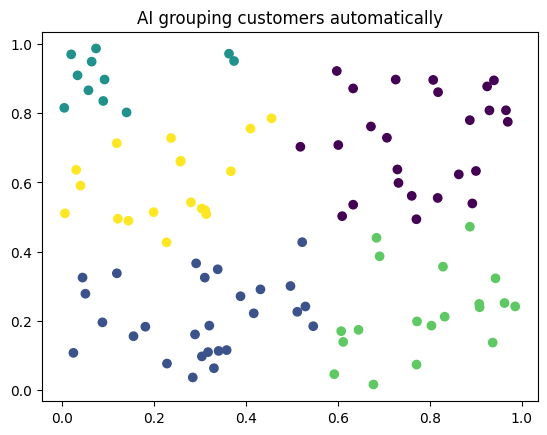

In [3]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# create fake data (age, spending)
np.random.seed(42)
data = np.random.rand(100,2)

# tell the ai: find a distinct groups (clusters) in this mess
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(data)

#see the results
plt.scatter(data[:, 0], data[:, 1], c=clusters, cmap='viridis')
plt.title('AI grouping customers automatically')
plt.show()



In [5]:
from sklearn.feature_extraction.text import CountVectorizer
v = ['antidisestablishmentarianism is a long word']
examples = CountVectorizer(ngram_range=(0,1))
example =examples.fit_transform(v)

print(examples.get_feature_names_out())
print(example)

['antidisestablishmentarianism' 'is' 'long' 'word']
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4 stored elements and shape (1, 4)>
  Coords	Values
  (0, 0)	1
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1


In [17]:
import whisper 
from pyannote.audio import Pipeline
import torch
from dotenv import load_dotenv
import os

load_dotenv()

HF_TOKEN = os.getenv('HF_TOKEN')
AUDIO_FILE = "/content/drive/MyDrive/output_path.wav"
pipeline = Pipeline.from_pretrained(
    "pyannote/speaker-diarization-3.1",
    token=HF_TOKEN
)


if torch.cuda.is_available():
    pipeline.to(torch.device('cuda'))

diarization = pipeline(AUDIO_FILE)

# transcription
model = whisper.load_model('base')
result = model.transcribe(AUDIO_FILE)

# we look at each transcribed segment and find the matching speaker
for segment in result['segments']:
    start_time = segment['start']
    text = segment['text']

    # find which speaker was active at this start time
    speaker_label = 'unknown'
    for turn, _, speaker in diarization.itertracks(yield_labe=True):
        if turn.start <= start_time <= turn.end:
            speaker_label =speaker
            break

    print(f"{speaker_label}: {text}")

In [ ]:
import os
print(f"Current Directory: {os.getcwd()}")
print(f"Files in /content/: {os.listdir('/content')}")

# This will return True or False
print(f"Is file found?: {os.path.exists('/content/drive/MyDrive/output_path.wav')}")


In [18]:
import torch
import torch.nn as nn

# 1. Create a model with 2 hidden neurons
class SpecialistNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 2 inputs (Money, Coffee) -> 2 hidden neurons
        self.hidden = nn.Linear(2, 2) 
        
        # MANUALLY setting weights to show "Reaction"
        with torch.no_grad():
            # Neuron A (Index 0) loves Money (1.0) and hates Coffee (0.0)
            # Neuron B (Index 1) hates Money (0.0) and loves Coffee (1.0)
            self.hidden.weight = nn.Parameter(torch.tensor([[1.0, 0.0],  # Neuron A
                                                            [0.0, 1.0]])) # Neuron B
            self.hidden.bias.fill_(0) # No offset for this test

    def forward(self, x):
        # We use ReLU so if the reaction is negative, it stays at 0 (Dark)
        return torch.relu(self.hidden(x))

model = SpecialistNet()

# 2. Test Input: An email about "Money" [1, 0]
money_email = torch.tensor([[1.0, 0.0]])
reaction = model(money_email)

print(f"Input: 'Money' email")
print(f"Neuron A (Spam) Reaction: {reaction[0][0].item():.1f} <-- GLOWING!")
print(f"Neuron B (Meeting) Reaction: {reaction[0][1].item():.1f} <-- DARK")

print("-" * 30)

# 3. Test Input: An email about "Coffee" [0, 1]
coffee_email = torch.tensor([[0.0, 1.0]])
reaction2 = model(coffee_email)

print(f"Input: 'Coffee' email")
print(f"Neuron A (Spam) Reaction: {reaction2[0][0].item():.1f} <-- DARK")
print(f"Neuron B (Meeting) Reaction: {reaction2[0][1].item():.1f} <-- GLOWING!")
